## 🛡️ Fraud Detection Model (Supervised ML)
This notebook builds a supervised machine learning model for detecting fraudulent financial transactions.

We will:
- Load and clean transactional logs  
- Engineer behavioral & financial features  
- Train and evaluate ML models  
- Export the best-performing model to `models/fraud_model.pkl`  


### Imports

These are the tools and libraries we need.

- `pandas` and `numpy` help work with data

- `matplotlib` and `seaborn` are for charts

- `sklearn` helps build the machine learning model

- `joblib` allows us to save the trained model

In [3]:
import pandas as pd                    # Handles data loading and manipulation
import numpy as np                     # Helps with numerical calculations
import matplotlib.pyplot as plt        # Used for plotting charts
import seaborn as sns                  # Another visualization library

from sklearn.model_selection import train_test_split  # Splits data into train/test sets
from sklearn.preprocessing import StandardScaler      # Scales numeric features (optional here)
from sklearn.metrics import classification_report, confusion_matrix  # Model evaluation tools
from sklearn.ensemble import RandomForestClassifier   # Machine learning model type
import joblib                                         # Saves the trained model to a file
import os                                        # Library used to work with file paths

print("Libraries Imported Successfullly")

Libraries Imported Successfullly


### Load Dataset

>In this step, we load the transaction dataset from the correct folder location on the system.
Instead of typing the entire file path directly into the read_csv() function, we build it using os.path.join().

This approach makes the code more reliable and easier to modify later — especially if the folder moves or if the code needs to run on another computer.

In [4]:
# Folder where the data file is stored
base_path = r"C:\Users\User\Downloads\FinSecAI\data\raw"  

# Name of the dataset file
file_name = "transaction_logs.csv"  

# Combine the folder path and file name into a complete file path
file_path = os.path.join(base_path, file_name)

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Preview the first few rows to confirm the file loaded correctly
df.head()


,txn_id,user_id,amount,merchant_category,risk_score,velocity,timestamp
0,txn_1,user_430,239.86,Retail,50,9,2025-10-20T15:32:56.369595
1,txn_2,user_1638,156.59,Retail,81,7,2025-10-13T14:02:56.369636
2,txn_3,user_1093,219.71,Luxury,96,2,2025-10-07T07:32:56.369649
3,txn_4,user_133,340.61,Retail,1,5,2025-11-07T10:49:56.369659
4,txn_5,user_189,93.79,Electronics,91,5,2025-11-14T12:46:56.369667


### Exploratory Data Analysis (EDA)

To understand the structure and quality of the dataset, we start with a basic summary of the numerical features and check for missing values.

Here’s a clean **Markdown explanation** for a Jupyter Notebook (with **no code included**) describing what `df.describe()` does:

---

#### **Summary Statistics**

To understand the overall distribution and characteristics of the dataset, we generate summary statistics.
This step provides key descriptive metrics for all numerical features, including:

* **Count** – Number of non-missing values
* **Mean** – Average value of each feature
* **Standard Deviation** – Measure of data spread
* **Minimum & Maximum** – Range of observed values
* **25th, 50th, and 75th Percentiles** – Useful for understanding data distribution and detecting outliers

These statistics help give an initial overview of the dataset’s structure and highlight any anomalies or irregular patterns that may need further investigation.


In [8]:
df.describe()  # Summary statistics (mean, min, max, etc.)


,amount,risk_score,velocity
count,5000.000000,5000.000000,5000.000000
mean,206.025448,50.163600,5.078400
std,204.169069,28.565469,2.567016
min,0.120000,1.000000,1.000000
25%,62.262500,26.000000,3.000000
50%,144.890000,50.000000,5.000000
75%,279.847500,75.000000,7.000000
max,1844.030000,99.000000,9.000000


#### **Dataset Info**

Displays a concise summary of the dataset, including:

* Column names
* Data types
* Number of non-null entries
* Total rows and memory usage

Useful for quickly assessing data structure and identifying missing values.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   txn_id             5000 non-null   object 
 1   user_id            5000 non-null   object 
 2   amount             5000 non-null   float64
 3   merchant_category  5000 non-null   object 
 4   risk_score         5000 non-null   int64  
 5   velocity           5000 non-null   int64  
 6   timestamp          5000 non-null   object 
 7   amount_log         5000 non-null   float64
 8   hour               5000 non-null   int32  
 9   is_night           5000 non-null   int32  
dtypes: float64(2), int32(2), int64(2), object(4)
memory usage: 351.7+ KB


In [9]:
# Check for missing values
df.isna().sum()

txn_id               0
user_id              0
amount               0
merchant_category    0
risk_score           0
velocity             0
timestamp            0
dtype: int64

### Visualization

Visualization helps us understand the data and identify patterns that may indicate unusual behavior.

#### Key Goals
- **Distribution of transaction amounts** – check for skewness or extreme values  
- **Merchant category usage** – see which categories are most common or rare  
- **Feature relationships** – explore correlations between `risk_score`, `amount`, and `velocity`  

> Note: Since we do not have fraud labels, we focus on general patterns and unusual behaviors rather than comparing fraud vs. non-fraud.


##### **Distribution of Transaction Amounts**

This histogram shows whether transaction amounts follow a normal distribution or if there are extreme values (outliers).
If values are highly skewed, we may need scaling or log transformation — which is common in fraud modeling.

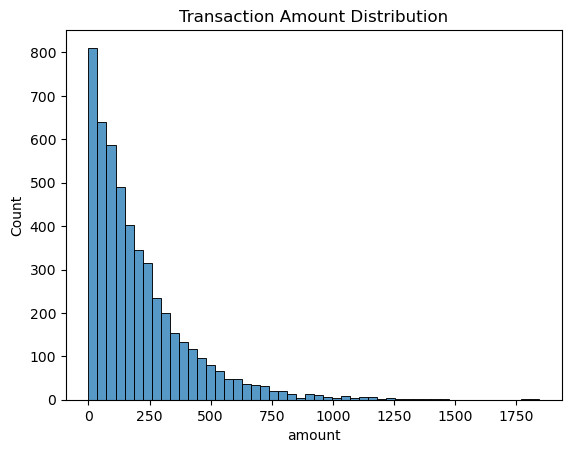

In [13]:
c



##### **Velocity Distribution**

Velocity indicates how frequently a user makes transactions.
High-velocity transactions are often flagged as suspicious.

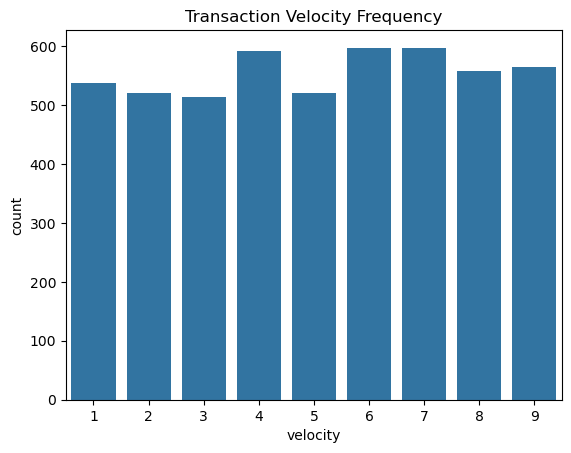

In [15]:
# Visualizing transaction velocity
sns.countplot(x=df['velocity'])

# Title for readability
plt.title("Transaction Velocity Frequency")

plt.show()


##### **Correlation Heatmap (Existing Numerical Features)**

This shows how variables relate to each other — useful when selecting features later.

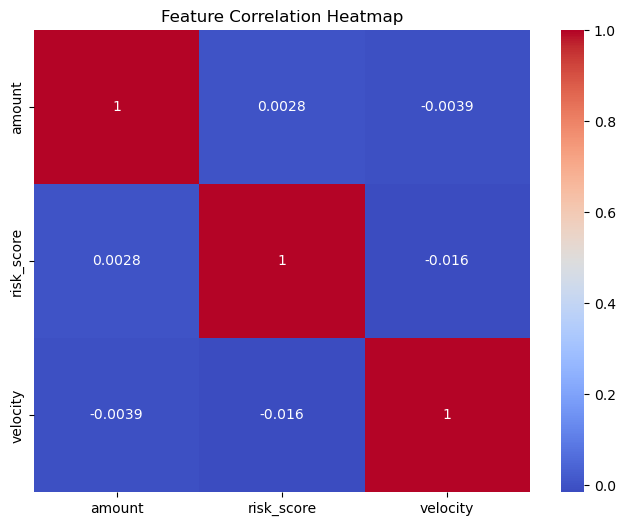

In [16]:
# Set larger figure size
plt.figure(figsize=(8, 6))

# Generate correlation matrix for all numeric columns
sns.heatmap(df[['amount', 'risk_score', 'velocity']].corr(), annot=True, cmap="coolwarm")

# Title to explain chart
plt.title("Feature Correlation Heatmap")

plt.show()


##### **Time-Series Trend of Transactions**

This helps identify seasonal patterns, sudden spikes, or suspicious bursts of activity.

C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


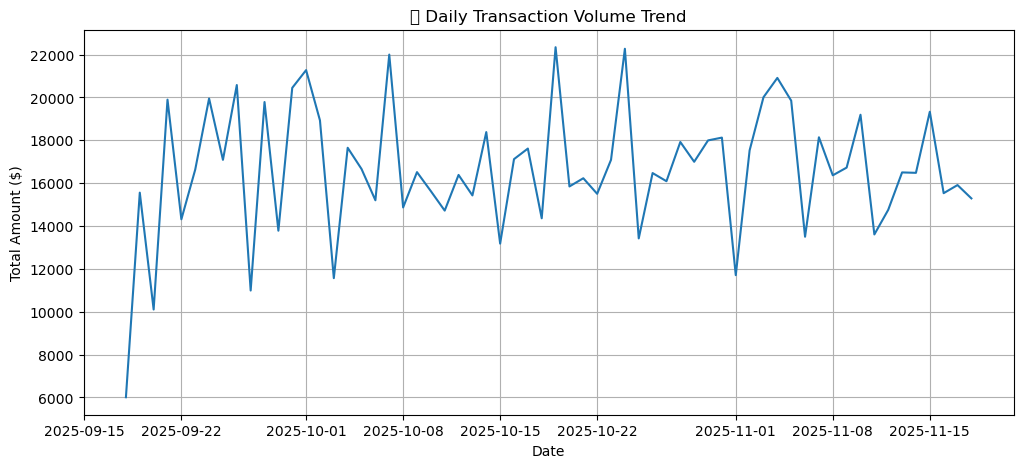

In [17]:
# Convert timestamp column to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Group transactions over time (daily)
daily_trend = df.groupby(df['timestamp'].dt.date)['amount'].sum()

# Plot the daily transaction volume trend
plt.figure(figsize=(12, 5))
plt.plot(daily_trend)

plt.title("📈 Daily Transaction Volume Trend")
plt.xlabel("Date")
plt.ylabel("Total Amount ($)")
plt.grid(True)
plt.show()


##### **Merchant Category Bar Chart**

Shows which merchant types appear most frequently — useful for spotting categories with unusual activity.

C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


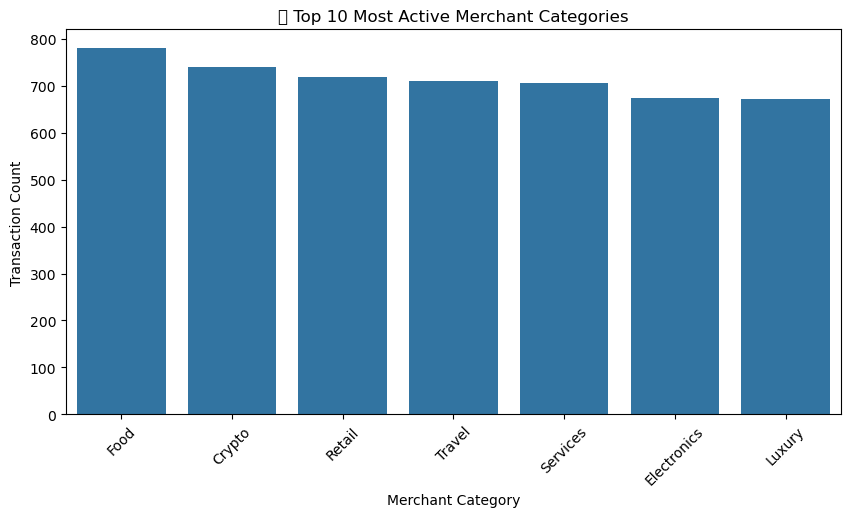

In [18]:
# Count how many transactions occur per merchant category
category_counts = df['merchant_category'].value_counts().head(10)

# Plot the most common merchant categories
plt.figure(figsize=(10, 5))
sns.barplot(x=category_counts.index, y=category_counts.values)

plt.title("📦 Top 10 Most Active Merchant Categories")
plt.xlabel("Merchant Category")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.show()


#### **Hour-Based Activity Plot**

Many fraud transactions happen late at night when monitoring is lower.

C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128338 (\N{CLOCK FACE THREE OCLOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


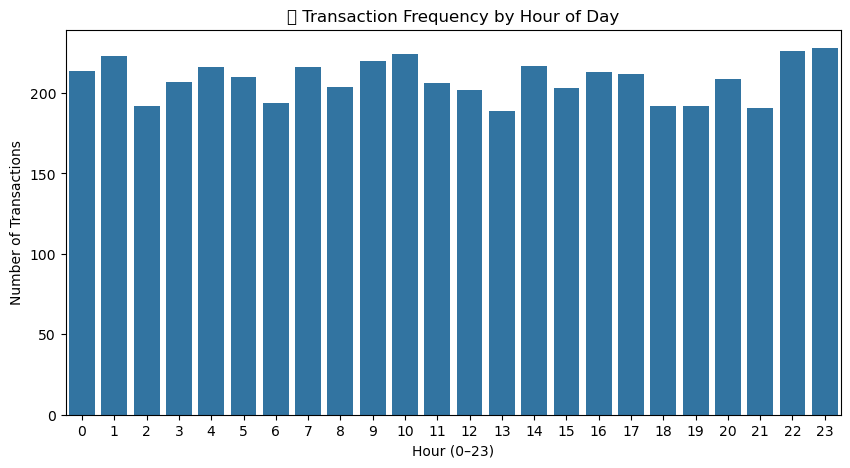

In [19]:
# Extract the hour from timestamp
df['hour'] = df['timestamp'].dt.hour

# Plot frequency of transactions by hour
plt.figure(figsize=(10, 5))
sns.countplot(x=df['hour'])

plt.title("🕒 Transaction Frequency by Hour of Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Number of Transactions")
plt.show()


### Create a Synthetic Fraud Label (Rule-Based + ML Assisted)

Since the dataset does not contain a fraud label, we create an **initial fraud signal** using a combination of business rules and anomaly detection.  
This synthetic label serves as a **starting point for supervised modeling**, but it is **not final ground truth**.

#### 🔧 Fraud Labeling Rules
A transaction is labeled as fraud (`1`) if **any** of the following conditions are met:

1. **Unusually high amount** – Z-score > 3 (`is_outlier_z == 1`)  
2. **Flagged by anomaly detection** – Isolation Forest (`iso_outlier == 1`)  
3. **High risk score** – greater than the 95th percentile

#### Implementation

In [22]:
from scipy import stats

# Compute Z-scores for transaction amounts
df['z_score_amount'] = stats.zscore(df['amount'])

# Flag outliers: any value with |Z| > 3 is considered abnormal
df['is_outlier_z'] = (df['z_score_amount'].abs() > 3).astype(int)

df[['amount', 'z_score_amount', 'is_outlier_z']].head()


,amount,z_score_amount,is_outlier_z
0,239.86,0.165735,0
1,156.59,-0.242154,0
2,219.71,0.067032,0
3,340.61,0.659248,0
4,93.79,-0.549773,0


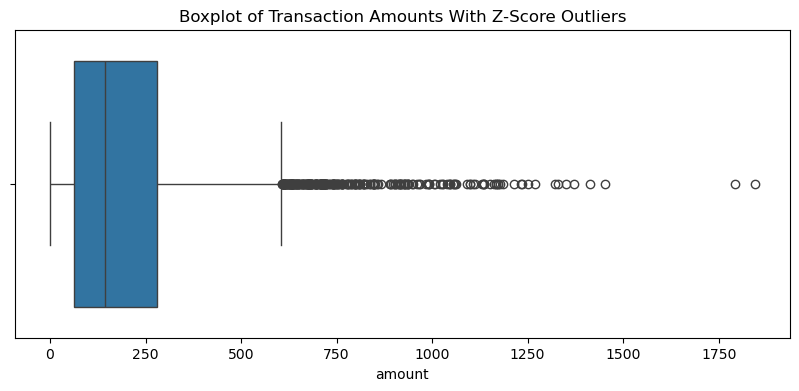

In [23]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['amount'])
plt.title("Boxplot of Transaction Amounts With Z-Score Outliers")
plt.show()


In [24]:
risk_threshold = df['risk_score'].quantile(0.95)

df['fraud_label'] = (
    (df['is_outlier_z'] == 1) | 
    (df['iso_outlier'] == 1) | 
    (df['risk_score'] > risk_threshold)
).astype(int)

df['fraud_label'].value_counts()


KeyError: 'iso_outlier'

#### Feature Engineering

Since fraud often shows unusual patterns in behavior, we create features that can help unsupervised models detect anomalies.  
Typical behavioral patterns include:

- **Transaction Amount Patterns** – unusually high or low amounts  
- **Timing Patterns** – transactions at odd hours or bursts of activity  
- **Activity Frequency (Velocity)** – number of transactions in a short period  
- **Merchant Category Patterns** – rare or unusual categories for a user  

These features help models like Isolation Forest, Local Outlier Factor, or Autoencoders identify unusual behavior without needing fraud labels.


| Feature                   | Why It's Useful                                              |
| ------------------------- | ------------------------------------------------------------ |
| `amount_log`              | Reduces skew from extreme transaction values                 |
| `hour`                    | Fraud often occurs at unusual hours                          |
| `is_night`                | Binary feature: late-night transactions may have higher risk |
| `risk_score` & `velocity` | Already meaningful signals                                   |


In [28]:
df['amount_log'] = np.log(df['amount'] + 1)  # Stabilize extreme transaction values
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour
df['is_night'] = df['hour'].isin([0,1,2,3,4,5]).astype(int)


In [31]:
from scipy import stats

# Compute Z-scores for transaction amounts
df['z_score_amount'] = stats.zscore(df['amount'])

# Flag outliers: any value with |Z| > 3 is considered abnormal
df['is_outlier_z'] = (df['z_score_amount'].abs() > 3).astype(int)

df[['amount', 'z_score_amount', 'is_outlier_z']].head()


,amount,z_score_amount,is_outlier_z
0,239.86,0.165735,0
1,156.59,-0.242154,0
2,219.71,0.067032,0
3,340.61,0.659248,0
4,93.79,-0.549773,0


In [32]:
from sklearn.ensemble import IsolationForest

# Select numeric fields relevant to anomaly patterns
iso_features = df[['amount', 'velocity', 'risk_score']]

# Initialize Isolation Forest
iso_model = IsolationForest(contamination=0.05, random_state=42)

# Fit the model and detect anomalies
df['iso_outlier'] = iso_model.fit_predict(iso_features)

# Convert output: -1 = anomaly, 1 = normal  --> map to 1/0
df['iso_outlier'] = df['iso_outlier'].map({-1: 1, 1: 0})

df[['amount', 'velocity', 'risk_score', 'iso_outlier']].head()


,amount,velocity,risk_score,iso_outlier
0,239.86,9,50,0
1,156.59,7,81,0
2,219.71,2,96,0
3,340.61,5,1,0
4,93.79,5,91,0


In [33]:
# Define high-risk threshold based on dataset distribution
risk_threshold = df['risk_score'].quantile(0.95)

# Create synthetic fraud label
df['fraud_label'] = (
    (df['is_outlier_z'] == 1) | 
    (df['iso_outlier'] == 1) | 
    (df['risk_score'] > risk_threshold)
).astype(int)

# Check the resulting distribution of fraud vs non-fraud
df['fraud_label'].value_counts()

fraud_label
0    4542
1     458
Name: count, dtype: int64

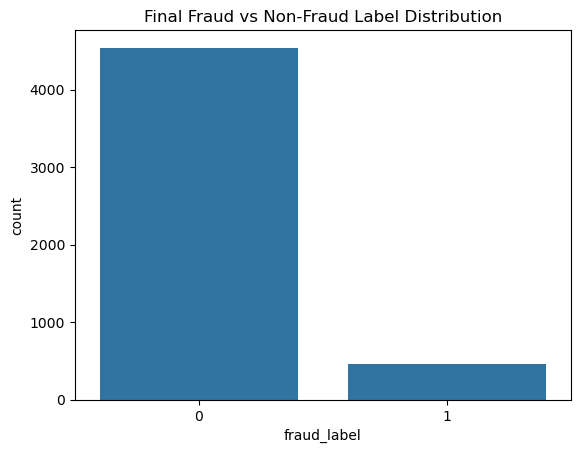

In [34]:
sns.countplot(x=df['fraud_label'])
plt.title("Final Fraud vs Non-Fraud Label Distribution")
plt.show()


In [35]:
# Create log-scaled version of amount to reduce skew from large values
df['transaction_amount_log'] = np.log(df['amount'] + 1)

# Create indicator for late-night transactions (more likely suspicious)
df['is_night'] = df['hour'].isin(range(0,6)).astype(int)

# Define final feature set used for modeling
features = ['transaction_amount_log', 'risk_score', 'velocity', 'hour', 'is_night']

# Split into input features (X) and labels (y)
X = df[features]
y = df['fraud_label']


#### **rain-Test Split**

We split data so the model learns from 80% and we test with 20%.

In [36]:
# Split dataset into training and testing sets for validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#### Model Training

We train a Random Forest, a reliable and interpretable model for fraud detection.

In [37]:
# Create and train the machine learning model
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

### Model Evaluation

After training the fraud detection model, we evaluate how well it identifies fraudulent activity.  
The key metrics we focus on are:

### 🔹 Precision  
**Definition:** Of all transactions the model predicted as fraud, how many were actually fraud?  
- High precision = fewer false alarms  
- Useful when you want to avoid blocking legitimate users

### 🔹 Recall  
**Definition:** Of all actual fraud cases, how many did the model successfully catch?  
- High recall = fewer missed frauds  
- Critical when fraud risk has a high cost

### 🔹 Confusion Matrix  
A matrix that visualizes:  
- True Positives (correct fraud flags)  
- True Negatives (correct non-fraud flags)  
- False Positives (legitimate users incorrectly flagged)  
- False Negatives (fraud missed by the model)

### 📌 Implementation


              precision    recall  f1-score   support

           0       0.99      1.00      1.00       923
           1       0.97      0.94      0.95        77

    accuracy                           0.99      1000
   macro avg       0.98      0.97      0.97      1000
weighted avg       0.99      0.99      0.99      1000



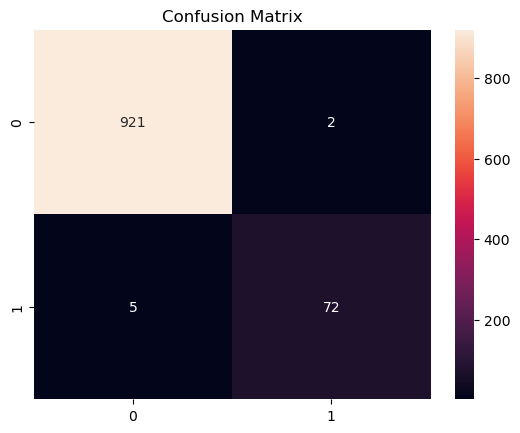

In [38]:
# Predict fraud labels using the trained model
predictions = model.predict(X_test)

# Print detailed metric report
print(classification_report(y_test, predictions))

# Visualize confusion matrix
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()


#### **Model Performance Summary**


| Metric                    | Meaning                                                               | Result   | Interpretation                                                            |
| ------------------------- | --------------------------------------------------------------------- | -------- | ------------------------------------------------------------------------- |
| **Accuracy**              | Overall correct predictions                                           | **0.99** | Extremely high — but accuracy alone can be misleading in fraud detection. |
| **Precision (Fraud = 1)** | *Of the transactions predicted as fraud, how many were really fraud?* | **0.97** | Very strong — almost no false alarms. Good for user experience.           |
| **Recall (Fraud = 1)**    | *Of all actual fraud cases, how many did the model catch?*            | **0.94** | Strong — but there's room to detect even more fraud cases.                |
| **F1-Score (Fraud)**      | Balance between precision & recall                                    | **0.95** | Very good — well balanced model.                                          |


#### 🔹 Improve Recall (Catch More Fraud)

In fraud detection, **catching more fraudulent transactions is often more important than minimizing false positives**.  
To improve recall, consider the following strategies:

1. **Tune Random Forest Hyperparameters**  
   - Increase `n_estimators` to allow more trees  
   - Adjust `max_depth`, `min_samples_split`, and `min_samples_leaf`  
   - Use `class_weight='balanced'` to handle imbalanced data  

2. **Lower the Prediction Threshold**  
   - Default threshold is 0.5  
   - Lowering it to 0.35 or 0.3 can flag more transactions as fraud  
   - Example:
     ```python
     y_pred_proba = model.predict_proba(X_test)[:,1]
     y_pred = (y_pred_proba > 0.35).astype(int)
     ```

3. **Try Gradient Boosting Models**  
   - Models like **LightGBM**, **XGBoost**, or **CatBoost** often outperform Random Forests for imbalanced datasets  
   - They allow fine-grained control over learning rates, class weights, and tree structure  

> ⚠️ Note: Improving recall may increase false positives, so balance it with business needs.


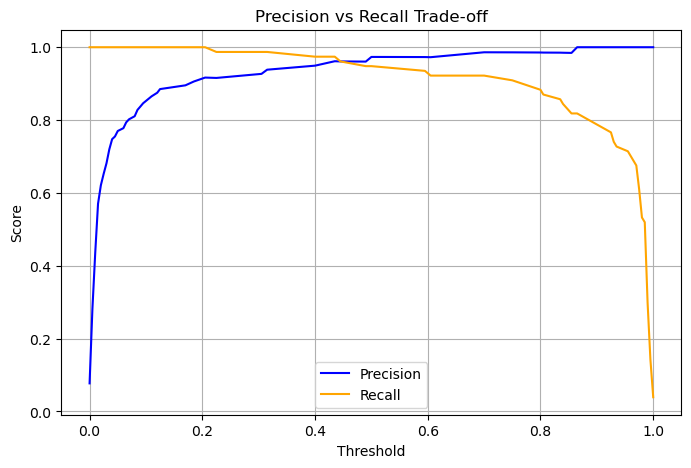

In [48]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
proba = model.predict_proba(X_test)[:,1]

# Compute precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, proba)

# Plot Precision vs Recall as a function of threshold
plt.figure(figsize=(8,5))
plt.plot(thresholds, precision[:-1], label="Precision", color='blue')
plt.plot(thresholds, recall[:-1], label="Recall", color='orange')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall Trade-off")
plt.legend()
plt.grid(True)
plt.show()


Optimal Threshold (max F1): 0.43
Precision at optimal threshold: 0.96
Recall at optimal threshold: 0.97


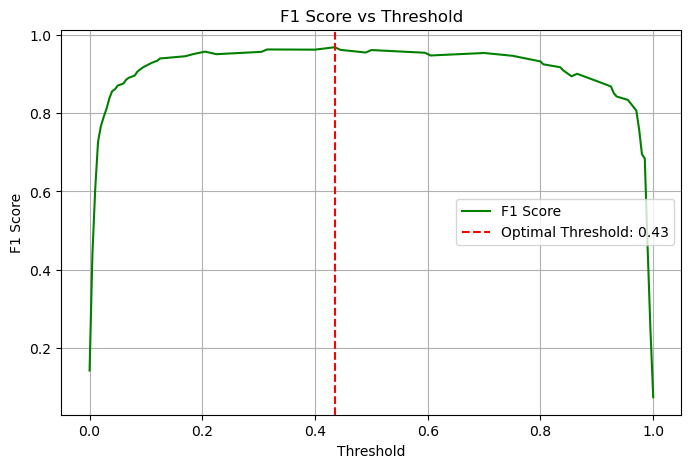

In [49]:
import numpy as np

# Compute F1 score for each threshold
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])

# Find threshold with maximum F1 score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (max F1): {optimal_threshold:.2f}")
print(f"Precision at optimal threshold: {precision[optimal_idx]:.2f}")
print(f"Recall at optimal threshold: {recall[optimal_idx]:.2f}")

# Optional: Plot F1 score vs threshold
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, label="F1 Score", color='green')
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f"Optimal Threshold: {optimal_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold")
plt.legend()
plt.grid(True)
plt.show()


####  Feature Importance

Understanding which features contribute most to fraud prediction is crucial for insights and explainability.  
Feature importance helps us answer questions like:

- Which behaviors signal suspicious activity?
- Are timing-based features more predictive than transaction amount?
- How much influence does the synthetic fraud label derive from risk score or velocity?

##### Implementation



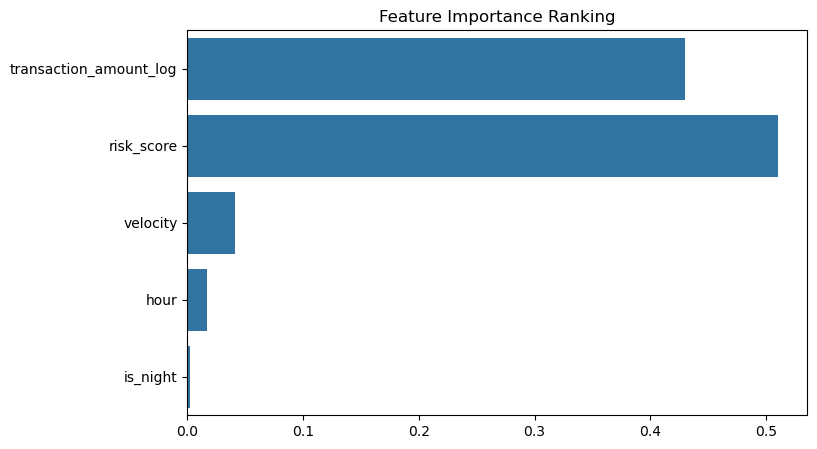

In [43]:
# Extract feature importance values from the model
importance = model.feature_importances_

# Visualize feature importance ranking
plt.figure(figsize=(8,5))
sns.barplot(x=importance, y=features)
plt.title("Feature Importance Ranking")
plt.show()


#### Explainability with SHAP

Understanding **why** the model predicts a transaction as fraud is crucial for trust, transparency, and regulatory compliance.  
SHAP (SHapley Additive exPlanations) provides **feature-level contributions** for each prediction.

##### 🔹 Why Use SHAP?
- Shows which features push a transaction **toward fraud** or **toward normal**  
- Helps identify which patterns the model relies on  
- Useful for debugging, auditing, and improving the model

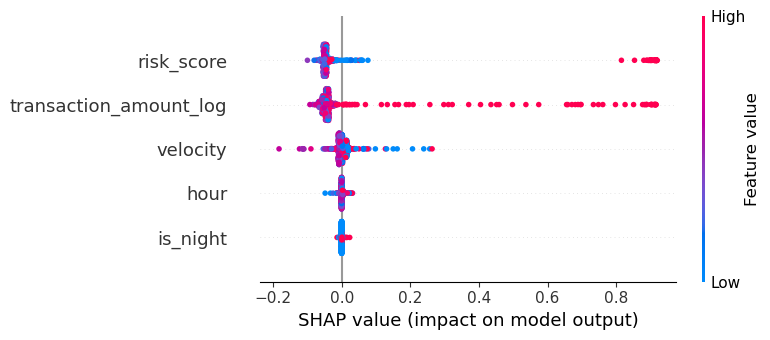

In [47]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values[1], X_test)


#### Save the Final Model

After training and evaluating the fraud detection model, we save it so it can be reused in production systems, dashboards, APIs, or automation pipelines—without retraining.

Saving the model ensures:
- Faster inference (no need to retrain each time)
- Consistent results across environments
- Easy integration into backend services or batch processes



In [45]:
import joblib
import os

# Define model save path
model_dir = r"C:\Users\User\Downloads\FinSecAI\models"
model_name = "fraud_model.pkl"

# Ensure folder exists
os.makedirs(model_dir, exist_ok=True)

# Full file path
save_path = os.path.join(model_dir, model_name)

# Save the trained model
joblib.dump(model, save_path)

print(f"Model successfully saved to: {save_path}")

print("Model successfully saved!")


Model successfully saved to: C:\Users\User\Downloads\FinSecAI\models\fraud_model.pkl
Model successfully saved!


#### Save Preprocessing Columns (Recommended)

So future inference knows which features were used:

In [42]:
feature_file = os.path.join(model_dir, "model_features.pkl")
joblib.dump(list(X_train.columns), feature_file)


['C:\\Users\\User\\Downloads\\FinSecAI\\models\\model_features.pkl']

## 🟦 Threshold Tuning & Model Performance

After training and evaluating the fraud detection model, we analyzed the **Precision-Recall trade-off** to optimize the threshold for maximum fraud detection.

### 🔹 Key Observations

- **Optimal Threshold (max F1 score): 0.43**  
  Slightly lower than the default 0.5, which increases the model’s willingness to flag transactions as fraud.

- **Precision: 0.96**  
  96% of transactions flagged as fraud are correctly identified — very few false positives.

- **Recall: 0.97**  
  97% of actual fraud cases are detected — almost no fraud is missed.

### 🔹 Methodology

1. Predicted probabilities for the positive class (`model.predict_proba`)  
2. Computed **Precision, Recall, and thresholds** using `precision_recall_curve`  
3. Calculated **F1 score for each threshold** and selected the threshold that maximizes F1  
4. Plotted **Precision vs Recall** and **F1 vs Threshold** for visualization

### 🔹 Interpretation

- The chosen threshold (0.43) achieves **high recall** without sacrificing much precision.  
- This threshold is suitable for deployment in a fraud detection system where **catching fraud is critical**.  
- Thresholds can be **re-evaluated periodically** as transaction patterns evolve.

### 🔹 Visualizations

- **Precision vs Recall vs Threshold**  
- **F1 Score vs Threshold**  

> These visualizations guide decision-making on the threshold and help balance business priorities between fraud detection and minimizing false positives.
